# **Example 08**: `solve_circuit_equations` with the toroidally conducting vacuum vessel

In [1]:
import gsfit_rs
import matplotlib.pyplot as plt
import numpy as np
from gsfit import Gsfit

In [ ]:
shot = 12612

gsfit_controller_bvl_only = Gsfit(
    pulseNo=shot,
    run_name="",
    run_description="BVL 15kA flat top",
    write_to_mds=False,
)
gsfit_controller_bvl_only.settings["GSFIT_code_settings.json"]["database_reader"]["st40_mdsplus"]["workflow"]["psu2coil"]["run_name"] = "RUN02"
gsfit_controller_bvl_only.set_environment_variables()
gsfit_controller_bvl_only.setup_timeslices()
gsfit_controller_bvl_only.setup_objects()

# Reminder: Rust objects are pointers, like Python dictionaries
bp_probes = gsfit_controller_bvl_only.bp_probes
coils = gsfit_controller_bvl_only.coils
passives = gsfit_controller_bvl_only.passives

2026-03-06 10:02:23  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_dialoop.json"
2026-03-06 10:02:23  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_isoflux.json"
2026-03-06 10:02:23  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "passive_dof_regularisation.json"
2026-03-06 10:02:23  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "source_function_p_prime.json"
2026-03-06 10:02:23  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "GSFIT_code_settings.json"
2026-03-06 10:02:23  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_flux_loops.json"
2026-03-06 10:02:23  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_pressure.json"
2026-03-06 10:02:23  |  GSFI

In [ ]:
## Remove all coils except the BVLB and BVLT coils
# coils.keys(["pf"])
coils.pop(["pf", "BVUB"])
coils.pop(["pf", "BVUT"])
coils.pop(["pf", "DIVB"])
coils.pop(["pf", "DIVT"])
coils.pop(["pf", "MCB"])
coils.pop(["pf", "MCT"])
coils.pop(["pf", "PSHB"])
coils.pop(["pf", "PSHT"])
coils.pop(["pf", "SOL"])
# Print which PF coils are left
coils.keys(["pf"])

['BVLB', 'BVLT']

In [ ]:
# Set time to solve circuit equations over
times_to_solve = np.linspace(-830.0e-3, 200e-3, 2000)

# Calcualte Greens, and solve circuit equations
gsfit_controller_bvl_only.calculate_greens()
coils.greens_with_self()
coils.calculate_coil_resistance()

gsfit_rs.solve_circuit_equations(
    coils,
    passives,
    times_to_solve,
    adaptive_time_stepping=False,
)

bp_probes.calculate_sensor_values_vacuum(
    coils,
    passives,
)

2026-03-06 09:39:44  |  GSFIT  |  gsfit.py:238                           |  INFO  |  Finished Greens with coils;  695.46ms
2026-03-06 09:40:14  |  GSFIT  |  gsfit.py:250                           |  INFO  |  Finished Greens with passives;  30,223.20ms
2026-03-06 09:40:16  |  GSFIT  |  gsfit.py:261                           |  INFO  |  Finished Greens with plasma;  1,380.43ms
Integration completed


Text(0.1, 0.02, 'We see that after ~-600 ms the BVLB/BVLT currents are flat.\nBut it takes another ~200 ms for the field to become constant.\nThis is due to the presence of the toroidally conducting vessel.')

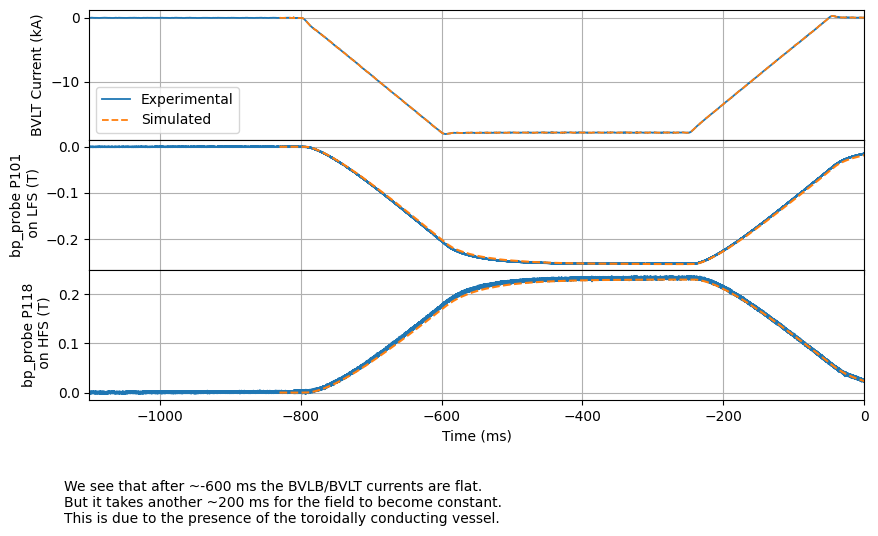

In [ ]:
fig, (ax_top, ax_middle, ax_bottom) = plt.subplots(
    3,
    1,
    sharex=True,
    gridspec_kw={"hspace": 0.0},
    figsize=(10, 6),
)

# Top subplot: BVLT current
ax_top.plot(
    coils.get_array1(["pf", "BVLT", "i", "experimental", "time"]) * 1.0e3,
    coils.get_array1(["pf", "BVLT", "i", "experimental", "value"]) / 1e3,
    linewidth=1.3,
    label="Experimental",
)
ax_top.plot(
    coils.get_array1(["pf", "BVLT", "i", "simulated", "time"]) * 1.0e3,
    coils.get_array1(["pf", "BVLT", "i", "simulated", "value"]) / 1e3,
    linestyle="--",
    linewidth=1.3,
    label="Simulated",
)
ax_top.legend()
ax_top.tick_params(axis="x", labelbottom=False)
ax_top.set_ylabel("BVLT Current (kA)")
ax_top.grid()

# Middle plot: bp_probe LFS
probe_name = "P101"
ax_middle.plot(
    bp_probes.get_array1([probe_name, "b", "experimental", "time"]) * 1.0e3,
    bp_probes.get_array1([probe_name, "b", "experimental", "value"]),
    label="Experimental",
)
ax_middle.plot(
    bp_probes.get_array1([probe_name, "b", "simulated", "time"]) * 1.0e3,
    bp_probes.get_array1([probe_name, "b", "simulated", "value"]),
    label="Simulated",
    linestyle="--",
)
ax_middle.set_ylabel(f"bp_probe {probe_name}\n on LFS (T)")
ax_middle.set_xlabel("Time (ms)")
ax_middle.grid()

# Bottom plot: bp_probe HFS
probe_name = "P118"
ax_bottom.plot(
    bp_probes.get_array1([probe_name, "b", "experimental", "time"]) * 1.0e3,
    bp_probes.get_array1([probe_name, "b", "experimental", "value"]),
    label="Experimental",
)
ax_bottom.plot(
    bp_probes.get_array1([probe_name, "b", "simulated", "time"]) * 1.0e3,
    bp_probes.get_array1([probe_name, "b", "simulated", "value"]),
    label="Simulated",
    linestyle="--",
)
ax_bottom.set_ylabel(f"bp_probe {probe_name}\n on HFS (T)")
ax_bottom.set_xlabel("Time (ms)")
ax_bottom.grid()
ax_bottom.set_xlim(-1.1e3, 0.0)

# Add text description
fig.subplots_adjust(bottom=0.23)
fig.text(
    0.1,
    0.02,
    "We see that after ~-600 ms the BVLB/BVLT currents are flat.\n"
    "But it takes another ~200 ms for the field to become constant.\n" \
    "This is due to the presence of the toroidally conducting vessel.",
    ha="left",
    va="bottom",
    fontsize=10,
)